In [2]:
# Importing all the req libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm


# Data Loading

In [3]:

FILEPATH = "https://raw.githubusercontent.com/smaswin21/gsk-ie-sales-model/main/sales.xlsx"

df = pd.read_excel(FILEPATH, header=[0,1,2])

df.head()

Unnamed: 0_level_0  Monthly Sales                           \
  Unnamed: 0_level_1 Sales in Units                            
         Hospital ID             M1   M2   M3   M4   M5   M6   
0         Hospital 1            826  665  933  864  788  918   
1         Hospital 2            346  306  311  411  341  461   
2         Hospital 3            239  222  252  331  364  112   
3         Hospital 4            341  411  471  336  637  441   
4         Hospital 5            501  185  276  371  371  451   

  Split Sales by Indication                            ... Indication C      \
                         M1                            ...  Touchpoints       
               Indication A Indication B Indication C  ...           M3  M4   
0                  0.862492     0.078961     0.058547  ...           74  12   
1                  0.768661     0.000000     0.231339  ...           20  12   
2                  0.503820     0.146947     0.349233  ...           56   8   
3                  0.485622     0.294316     0.220062  ...           20  22   
4                  0.610392     0.180116     0.209492  ...           34  12   

                                    
          HCPs                      
   M5  M6   M1  M2  M3  M4  M5  M6  
0  16  36   24  32  46  12  14  26  
1   2   4   10  18  16  12   2   4  
2   0  14   18  22  38   8   0  10  
3   8  20    4  12  18  10   8   8  
4   0   4   10  20  24  12   0   4  

[5 rows x 61 columns]

### Cleaning multi-index columns

In [4]:
# Replace Unnamed with empty string
df.columns = pd.MultiIndex.from_tuples(
    [(str(a) if "Unnamed" not in str(a) else "",
      str(b) if "Unnamed" not in str(b) else "",
      str(c) if "Unnamed" not in str(c) else "")
     for a, b, c in df.columns]
)

# Flatten columns
df.columns = [
    "_".join([level for level in col if level != ""])
    for col in df.columns
]

df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)
df.head()

Index(['hospital_id', 'monthly_sales_sales_in_units_m1',
       'monthly_sales_sales_in_units_m2', 'monthly_sales_sales_in_units_m3',
       'monthly_sales_sales_in_units_m4', 'monthly_sales_sales_in_units_m5',
       'monthly_sales_sales_in_units_m6',
       'split_sales_by_indication_m1_indication_a',
       'split_sales_by_indication_m1_indication_b',
       'split_sales_by_indication_m1_indication_c',
       'split_sales_by_indication_m2_indication_a',
       'split_sales_by_indication_m2_indication_b',
       'split_sales_by_indication_m2_indication_c',
       'split_sales_by_indication_m3_indication_a',
       'split_sales_by_indication_m3_indication_b',
       'split_sales_by_indication_m3_indication_c',
       'split_sales_by_indication_m4_indication_a',
       'split_sales_by_indication_m4_indication_b',
       'split_sales_by_indication_m4_indication_c',
       'split_sales_by_indication_m5_indication_a',
       'split_sales_by_indication_m5_indication_b',
       'split_sales

,hospital_id,monthly_sales_sales_in_units_m1,monthly_sales_sales_in_units_m2,monthly_sales_sales_in_units_m3,monthly_sales_sales_in_units_m4,monthly_sales_sales_in_units_m5,monthly_sales_sales_in_units_m6,split_sales_by_indication_m1_indication_a,split_sales_by_indication_m1_indication_b,split_sales_by_indication_m1_indication_c,...,indication_c_touchpoints_m3,indication_c_touchpoints_m4,indication_c_touchpoints_m5,indication_c_touchpoints_m6,indication_c_hcps_m1,indication_c_hcps_m2,indication_c_hcps_m3,indication_c_hcps_m4,indication_c_hcps_m5,indication_c_hcps_m6
0,Hospital 1,826,665,933,864,788,918,0.862492,0.078961,0.058547,...,74,12,16,36,24,32,46,12,14,26
1,Hospital 2,346,306,311,411,341,461,0.768661,0.000000,0.231339,...,20,12,2,4,10,18,16,12,2,4
2,Hospital 3,239,222,252,331,364,112,0.503820,0.146947,0.349233,...,56,8,0,14,18,22,38,8,0,10
3,Hospital 4,341,411,471,336,637,441,0.485622,0.294316,0.220062,...,20,22,8,20,4,12,18,10,8,8
4,Hospital 5,501,185,276,371,371,451,0.610392,0.180116,0.209492,...,34,12,0,4,10,20,24,12,0,4


In [5]:
sales_cols = [c for c in df.columns if "monthly_sales" in c]
split_cols = [c for c in df.columns if "split_sales_by_indication" in c]

print("Sales columns:", sales_cols)
print("Split columns (first 10):", split_cols[:10])

Sales columns: ['monthly_sales_sales_in_units_m1', 'monthly_sales_sales_in_units_m2', 'monthly_sales_sales_in_units_m3', 'monthly_sales_sales_in_units_m4', 'monthly_sales_sales_in_units_m5', 'monthly_sales_sales_in_units_m6']
Split columns (first 10): ['split_sales_by_indication_m1_indication_a', 'split_sales_by_indication_m1_indication_b', 'split_sales_by_indication_m1_indication_c', 'split_sales_by_indication_m2_indication_a', 'split_sales_by_indication_m2_indication_b', 'split_sales_by_indication_m2_indication_c', 'split_sales_by_indication_m3_indication_a', 'split_sales_by_indication_m3_indication_b', 'split_sales_by_indication_m3_indication_c', 'split_sales_by_indication_m4_indication_a']


#### Units sold across M1–M6 for each hospital:

In [6]:
df["total_6m_sales"] = df[sales_cols].sum(axis=1)

df["total_6m_sales"].describe()

count     100.000000
mean     1622.190000
std      1148.773845
min        35.000000
25%       823.250000
50%      1343.000000
75%      2160.250000
max      6716.000000
Name: total_6m_sales, dtype: float64

#### One average split per indication per hospital (hospital-level):

In [7]:
indications = sorted(
    list(set([c.split("_indication_")[-1] for c in split_cols]))
)

avg_split_dict = {}

for ind in indications:
    ind_cols = [c for c in split_cols if f"_indication_{ind}" in c]
    avg_split_dict[ind] = df[ind_cols].mean(axis=1)

avg_split_df = pd.DataFrame(avg_split_dict)

avg_split_df["hospital_id"] = df["hospital_id"]

avg_split_df = avg_split_df[["hospital_id"] + indications]

avg_split_df["sum_split"] = avg_split_df[indications].sum(axis=1) # To check if the avg split works: should be 1

avg_split_df.head(10)


,hospital_id,a,b,c,sum_split
0,Hospital 1,0.850221,0.086010,0.063769,1.0
1,Hospital 2,0.720456,0.016333,0.263210,1.0
2,Hospital 3,0.478491,0.243341,0.278168,1.0
3,Hospital 4,0.469818,0.246760,0.283423,1.0
4,Hospital 5,0.560944,0.162814,0.276243,1.0
5,Hospital 6,0.752017,0.176134,0.071849,1.0
6,Hospital 7,0.597793,0.259541,0.142666,1.0
7,Hospital 8,0.790801,0.121535,0.087663,1.0
8,Hospital 9,0.906125,0.023003,0.070872,1.0
9,Hospital 10,0.858335,0.031681,0.109984,1.0


# EDA

## How different are hospitals?

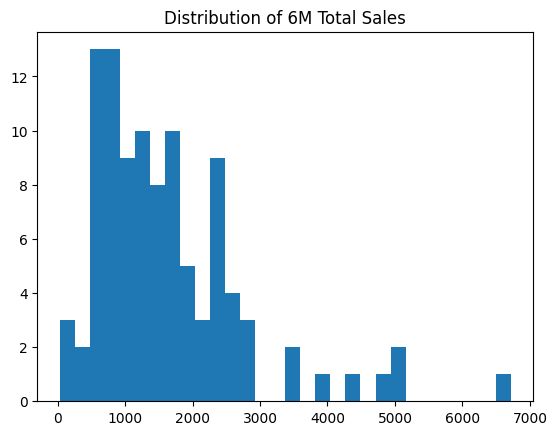

In [8]:
plt.figure()
plt.hist(df["total_6m_sales"], bins=30)
plt.title("Distribution of 6M Total Sales")
plt.show()

Sales are right-skewed: a few high-volume hospitals driving the upper tail

Most hospitals fall between 500–2,500 units.

Mid-sized hospitals dominate.

Very few sell extremely little or extremely high amounts

Strong heterogeneity across hospitals: size may influence indication split modeling -> future log transformation

In [9]:
df["total_6m_sales"].describe()

count     100.000000
mean     1622.190000
std      1148.773845
min        35.000000
25%       823.250000
50%      1343.000000
75%      2160.250000
max      6716.000000
Name: total_6m_sales, dtype: float64

### Comparing hospitals by indication split

In [10]:
avg_split_df[indications].describe()

,a,b,c
count,100.000000,100.000000,100.000000
mean,0.665098,0.164093,0.170809
std,0.173737,0.136665,0.148869
min,0.208473,0.000000,0.000000
25%,0.561700,0.071813,0.050288
50%,0.689574,0.122128,0.158206
75%,0.812621,0.247044,0.266157
max,1.000000,0.568433,0.595811


In [11]:
avg_split_df["dominant_indication"] = avg_split_df[indications].idxmax(axis=1)

avg_split_df["dominant_indication"].value_counts()

dominant_indication
a    89
b     6
c     5
Name: count, dtype: int64

The market is heavily skewed toward Indication A: Most hospitals prescribe this drug primarily for A

Possible meanings:
- Indication A is likely the core therapeutic area

- B and C may represent niche or smaller patient populations

- A naive average-split model would already be biased toward A

In [12]:
# do big hospitals behave differently?
df["size_group"] = pd.qcut(df["total_6m_sales"], q=3, labels=["Small", "Medium", "Large"])

pd.concat([df["size_group"], avg_split_df[indications]], axis=1)\
  .groupby("size_group").mean()

,a,b,c
size_group,,,
Small,0.659732,0.224369,0.115899
Medium,0.663504,0.103123,0.233373
Large,0.672222,0.162959,0.164819


- Indication A share is relatively stable across Small, Medium, and Large hospitals (~66–67%).

- Smaller hospitals show a higher share of Indication B, while medium hospitals show a higher share of Indication C.

- Hospital size contributes to heterogeneity in indication allocation and will probably be an important modeling variable.

## Data quality



In [13]:
print(f"Dataset shape: {df.shape}")
print(f"Number of hospitals: {df['hospital_id'].nunique()}")
print(f"\n--- Data Types Summary ---")
print(df.dtypes.value_counts())


Dataset shape: (100, 63)
Number of hospitals: 100

--- Data Types Summary ---
int64       43
float64     18
object       1
category     1
Name: count, dtype: int64


In [14]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]
if len(missing_report) == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\n--- Missing Values ---")
    print(missing_report)



No missing values found in the dataset.


In [15]:
# Check if indication splits sum to 1 for each month

print("\n--- Indication Split Sum Check (per month) ---")
for m in range(1, 7):
    split_sum = (
        df[f'split_sales_by_indication_m{m}_indication_a'] +
        df[f'split_sales_by_indication_m{m}_indication_b'] +
        df[f'split_sales_by_indication_m{m}_indication_c']
    )
    not_one = (split_sum - 1.0).abs() > 1e-6
    if not_one.any():
        print(f"  M{m}: {not_one.sum()} hospitals have splits NOT summing to 1")
        print(f"       Range of sums: [{split_sum[not_one].min():.6f}, {split_sum[not_one].max():.6f}]")
    else:
        print(f"  M{m}: All hospitals sum to 1.0")



--- Indication Split Sum Check (per month) ---
  M1: All hospitals sum to 1.0
  M2: All hospitals sum to 1.0
  M3: All hospitals sum to 1.0
  M4: All hospitals sum to 1.0
  M5: All hospitals sum to 1.0
  M6: All hospitals sum to 1.0


In [16]:
# Check for any zero/negative sales
print("\n--- Zero or Negative Monthly Sales ---")
for m in range(1, 7):
    col = f'monthly_sales_sales_in_units_m{m}'
    zero_count = (df[col] <= 0).sum()
    if zero_count > 0:
        print(f"  M{m}: {zero_count} hospitals with zero or negative sales")
    else:
        print(f"  M{m}: All sales positive")


--- Zero or Negative Monthly Sales ---
  M1: All sales positive
  M2: All sales positive
  M3: All sales positive
  M4: All sales positive
  M5: All sales positive
  M6: All sales positive


### Sales Distribution Analysis

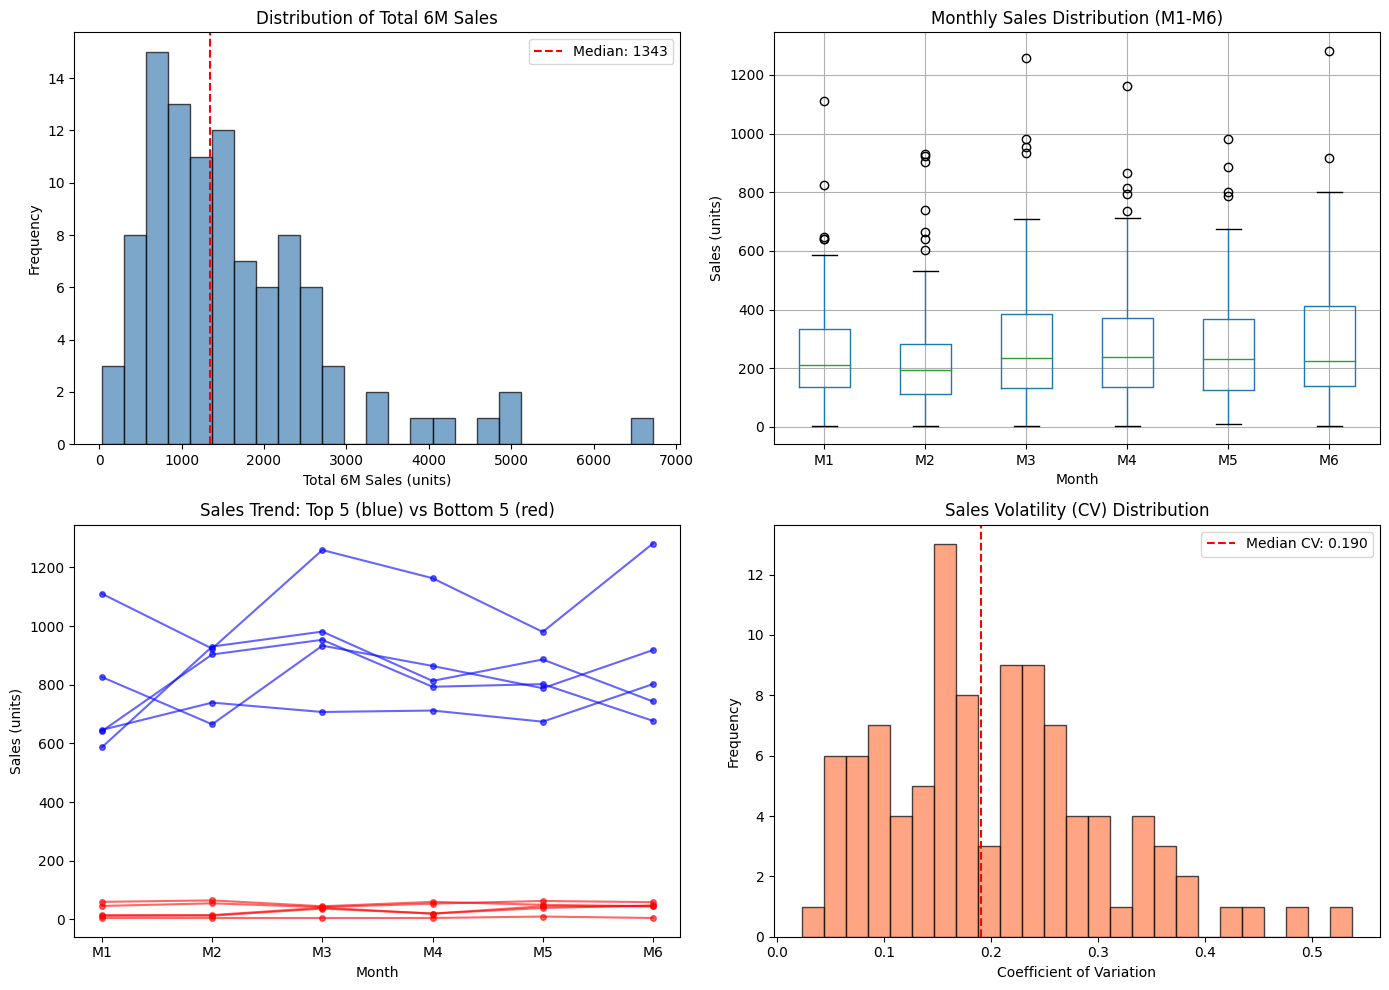

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Histogram of total 6M sales
axes[0, 0].hist(df['total_6m_sales'], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Total 6M Sales')
axes[0, 0].set_xlabel('Total 6M Sales (units)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['total_6m_sales'].median(), color='red', linestyle='--', label=f"Median: {df['total_6m_sales'].median():.0f}")
axes[0, 0].legend()

# (b) Boxplot of monthly sales across M1-M6
monthly_data = df[[f'monthly_sales_sales_in_units_m{m}' for m in range(1, 7)]]
monthly_data.columns = [f'M{m}' for m in range(1, 7)]
monthly_data.boxplot(ax=axes[0, 1])
axes[0, 1].set_title('Monthly Sales Distribution (M1-M6)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Sales (units)')

# (c) Sales trend line for top 5 and bottom 5 hospitals
top5 = df.nlargest(5, 'total_6m_sales')
bottom5 = df.nsmallest(5, 'total_6m_sales')
months = range(1, 7)
for _, row in top5.iterrows():
    vals = [row[f'monthly_sales_sales_in_units_m{m}'] for m in months]
    axes[1, 0].plot(months, vals, 'b-o', alpha=0.6, markersize=4)
for _, row in bottom5.iterrows():
    vals = [row[f'monthly_sales_sales_in_units_m{m}'] for m in months]
    axes[1, 0].plot(months, vals, 'r-o', alpha=0.6, markersize=4)
axes[1, 0].set_title('Sales Trend: Top 5 (blue) vs Bottom 5 (red)')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Sales (units)')
axes[1, 0].set_xticks(list(months))
axes[1, 0].set_xticklabels([f'M{m}' for m in months])

# (d) Coefficient of variation per hospital (sales volatility)
monthly_sales_df = df[[f'monthly_sales_sales_in_units_m{m}' for m in range(1, 7)]]
cv = monthly_sales_df.std(axis=1) / monthly_sales_df.mean(axis=1)
axes[1, 1].hist(cv, bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Sales Volatility (CV) Distribution')
axes[1, 1].set_xlabel('Coefficient of Variation')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(cv.median(), color='red', linestyle='--', label=f"Median CV: {cv.median():.3f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()



####  Insights

- Total 6M sales are right-skewed with most hospitals in the 500-2500 range and a long upper tail.
- Monthly sales distributions appear more or less stable across M1-M6, showing that there's no strong seasonal pattern at the aggregate level.
- Top 5 hospitals have vastly different magnitudes compared to bottom 5, confirming strong heterogeneity.
- Sales volatility (CV) varies considerably across hospitals - some have very stable month-to-month sales while others fluctuate significantly.

### Indication Split Analysis

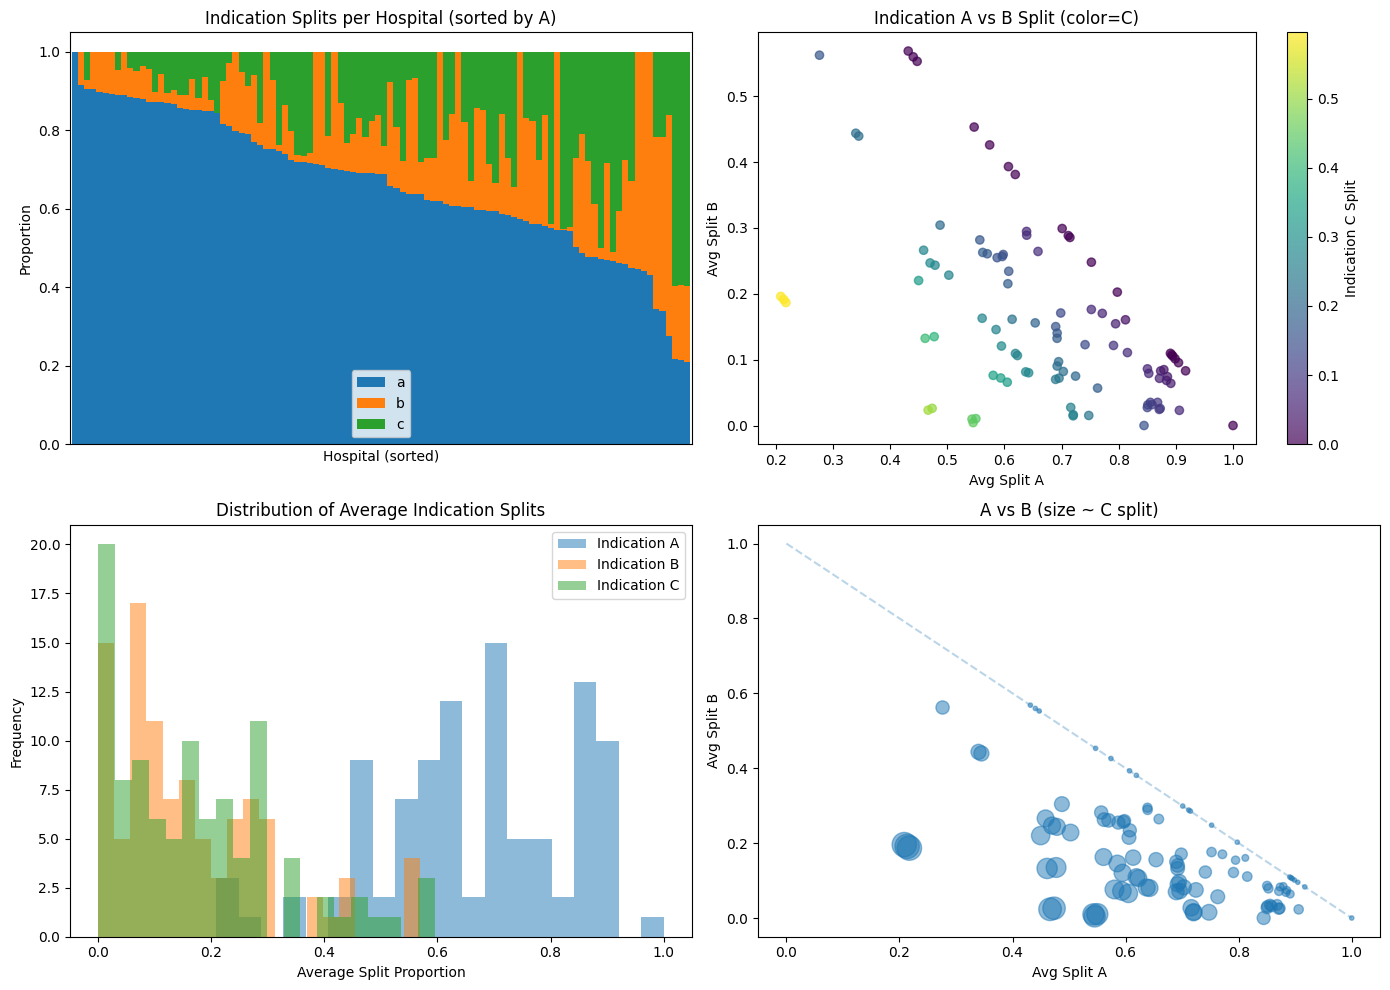

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Stacked bar chart
sorted_idx = avg_split_df['a'].sort_values(ascending=False).index
avg_split_df.loc[sorted_idx, indications].plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 0],
    width=1.0
)

axes[0, 0].set(
    title='Indication Splits per Hospital (sorted by A)',
    xlabel='Hospital (sorted)',
    ylabel='Proportion'
)
axes[0, 0].set_xticks([])


# (2) Scatter A vs B (color = C)
sc = axes[0, 1].scatter(
    avg_split_df['a'],
    avg_split_df['b'],
    c=avg_split_df['c'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(sc, ax=axes[0, 1], label='Indication C Split')
axes[0, 1].set(
    title='Indication A vs B Split (color=C)',
    xlabel='Avg Split A',
    ylabel='Avg Split B'
)


# (3) Distribution histograms
for ind in indications:
    axes[1, 0].hist(avg_split_df[ind], bins=20, alpha=0.5, label=f'Indication {ind.upper()}')

axes[1, 0].set(
    title='Distribution of Average Indication Splits',
    xlabel='Average Split Proportion',
    ylabel='Frequency'
)
axes[1, 0].legend()


# (4) A vs B (size ~ C)
sizes = avg_split_df['c'] * 500 + 10
axes[1, 1].scatter(
    avg_split_df['a'],
    avg_split_df['b'],
    s=sizes,
    alpha=0.5
)

axes[1, 1].plot([0, 1], [1, 0], '--', alpha=0.3)
axes[1, 1].set(
    title='A vs B (size ~ C split)',
    xlabel='Avg Split A',
    ylabel='Avg Split B'
)

plt.tight_layout()
plt.show()

**Indication Split Observations:**


- Indication A is significantly higher for the vast majority of hospitals (mean
66.5%), with some hospitals at nearly 100%.
- Indications B and C have similar mean shares (16-17%) but with high variance.
- There is a clear negative correlation between A and B/C splits (compositional data constraint: they must sum to 1).
- The ternary view shows that most hospitals cluster in the high-A, low-B, low-C region, but a subset shows more balanced splits.
- Some hospitals have zero B or C splits, maybe showing complete specialization.

### Touchpoint and HCP Analysis

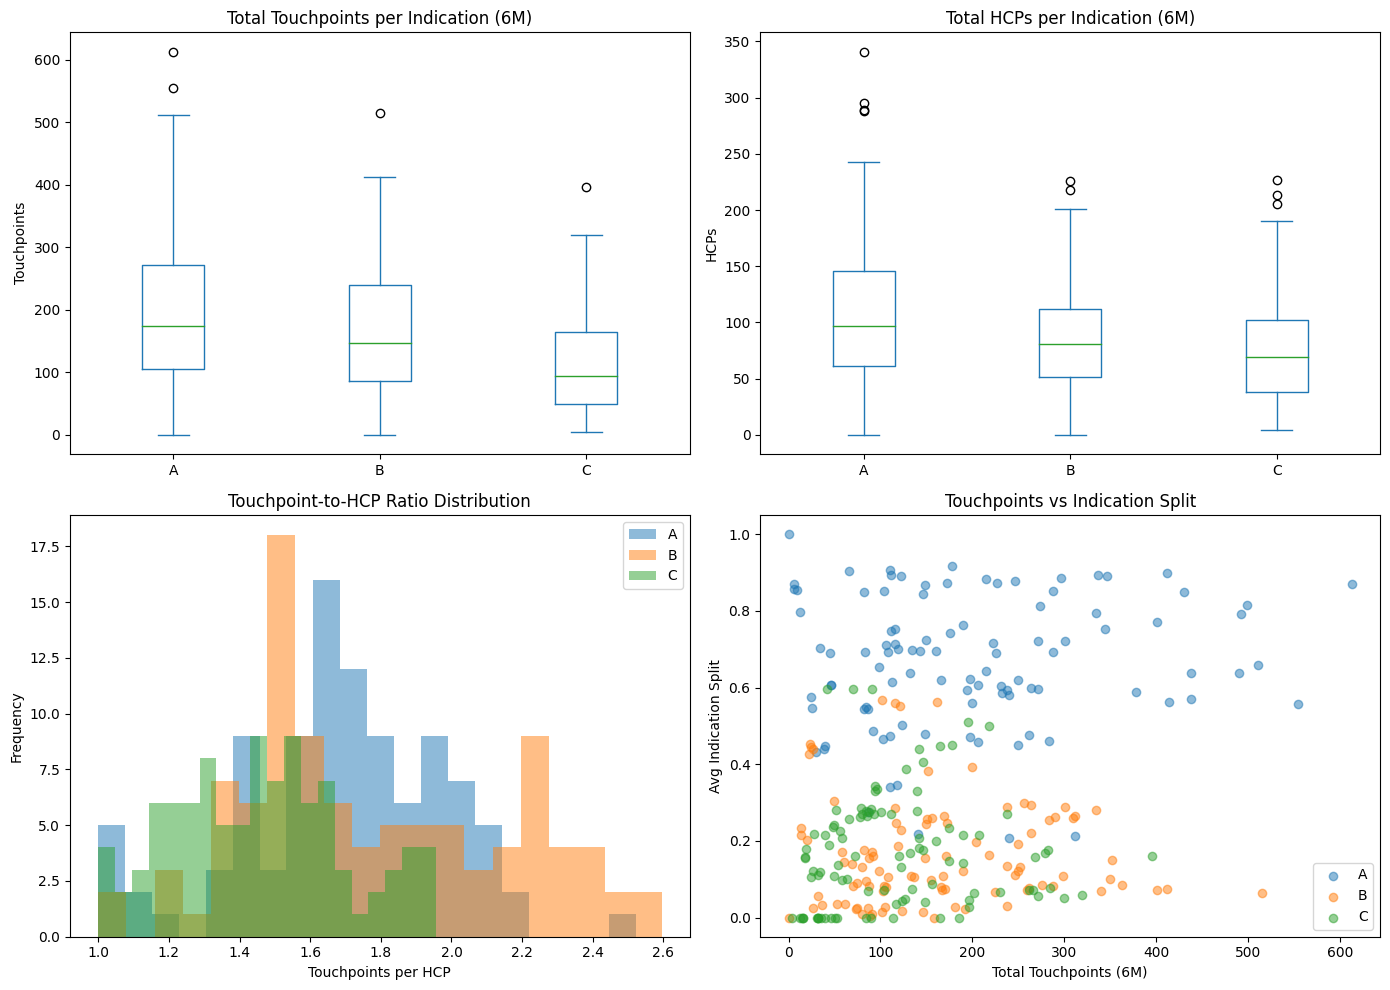

In [19]:
# Aggregate totals
for ind in indications:
    tp_cols = [f'indication_{ind}_touchpoints_m{m}' for m in range(1, 7)]
    hcp_cols = [f'indication_{ind}_hcps_m{m}' for m in range(1, 7)]
    df[f'total_touchpoints_{ind}'] = df[tp_cols].sum(axis=1)
    df[f'total_hcps_{ind}'] = df[hcp_cols].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Touchpoints distribution
df[[f'total_touchpoints_{ind}' for ind in indications]] \
    .set_axis(['A', 'B', 'C'], axis=1) \
    .plot(kind='box', ax=axes[0, 0])

axes[0, 0].set(title='Total Touchpoints per Indication (6M)', ylabel='Touchpoints')


# (b) HCP distribution
df[[f'total_hcps_{ind}' for ind in indications]] \
    .set_axis(['A', 'B', 'C'], axis=1) \
    .plot(kind='box', ax=axes[0, 1])

axes[0, 1].set(title='Total HCPs per Indication (6M)', ylabel='HCPs')


# (c) Touchpoint-to-HCP ratio
for ind in indications:
    ratio = df[f'total_touchpoints_{ind}'] / df[f'total_hcps_{ind}']
    axes[1, 0].hist(ratio.replace([np.inf, -np.inf], np.nan).dropna(),
                    bins=20, alpha=0.5, label=ind.upper())

axes[1, 0].set(
    title='Touchpoint-to-HCP Ratio Distribution',
    xlabel='Touchpoints per HCP',
    ylabel='Frequency'
)
axes[1, 0].legend()


# (d) Touchpoints vs split
for ind in indications:
    axes[1, 1].scatter(
        df[f'total_touchpoints_{ind}'],
        avg_split_df[ind],
        alpha=0.5,
        label=ind.upper()
    )

axes[1, 1].set(
    title='Touchpoints vs Indication Split',
    xlabel='Total Touchpoints (6M)',
    ylabel='Avg Indication Split'
)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

**Touchpoint & HCP Observations:**


- Indication A generally receives more touchpoints and HCPs, consistent with its dominant sales share.
- The touchpoint-to-HCP ratio varies across indications, showing different engagement strategies per indication.
- There is a positive association between touchpoints and the corresponding indication split, suggesting commercial activity may influence (or reflect) indication allocation.
- Some hospitals have very few or zero touchpoints for indications B and C.

### Correlation Analysis

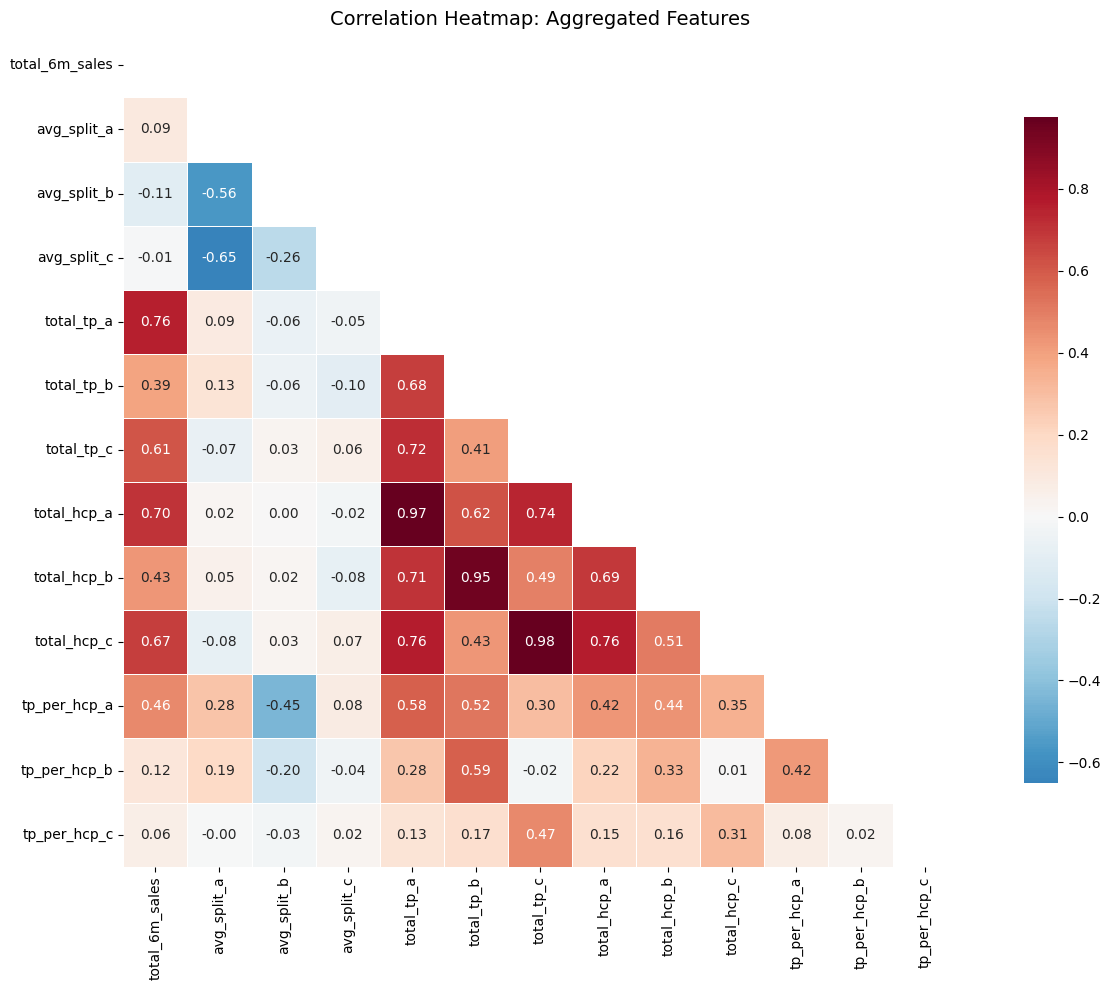

In [20]:
# --- I'm building an aggregated feature set which will help for correlation analysis ---

corr_df = pd.DataFrame({
    'total_6m_sales': df['total_6m_sales'],
    'avg_split_a': avg_split_df['a'],
    'avg_split_b': avg_split_df['b'],
    'avg_split_c': avg_split_df['c'],
    'total_tp_a': df['total_touchpoints_a'],
    'total_tp_b': df['total_touchpoints_b'],
    'total_tp_c': df['total_touchpoints_c'],
    'total_hcp_a': df['total_hcps_a'],
    'total_hcp_b': df['total_hcps_b'],
    'total_hcp_c': df['total_hcps_c'],
})

# Add TP/HCP ratios
for ind in indications:
    corr_df[f'tp_per_hcp_{ind}'] = np.where(
        df[f'total_hcps_{ind}'] > 0,
        df[f'total_touchpoints_{ind}'] / df[f'total_hcps_{ind}'],
        np.nan
    )

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap: Aggregated Features', fontsize=14)
plt.tight_layout()
plt.show()

**Correlation Insights:**

- Total sales are positively correlated with touchpoints and HCPs across all indications (larger hospitals get more commercial attention).
- Indication splits (A, B, C) are negatively correlated with each other due to the compositional constraint.
- Touchpoints for a given indication tend to correlate positively with its corresponding sales split.
- The TP/HCP ratio features may capture engagement intensity beyond just volume.

### Monthly Trends

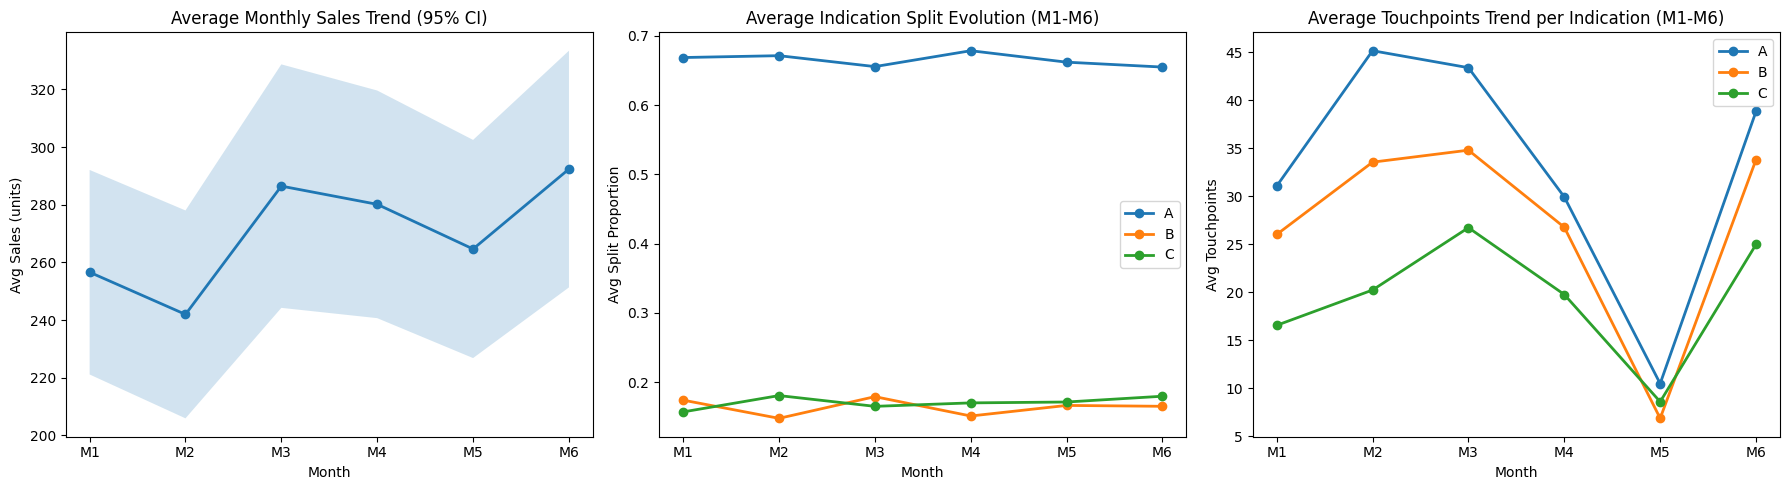

In [21]:
months = range(1, 7)
month_labels = [f'M{m}' for m in months]

def monthly_mean(pattern):
    """Return list of monthly means given a column name pattern with {m}."""
    return [df[pattern.format(m=m)].mean() for m in months]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Sales trend with 95% CI
avg_sales = monthly_mean('monthly_sales_sales_in_units_m{m}')
se_sales = [
    df[f'monthly_sales_sales_in_units_m{m}'].std() / np.sqrt(len(df))
    for m in months
]

axes[0].plot(months, avg_sales, '-o', linewidth=2)
axes[0].fill_between(
    months,
    [a - 1.96*s for a, s in zip(avg_sales, se_sales)],
    [a + 1.96*s for a, s in zip(avg_sales, se_sales)],
    alpha=0.2
)

axes[0].set(
    title='Average Monthly Sales Trend (95% CI)',
    xlabel='Month',
    ylabel='Avg Sales (units)'
)
axes[0].set_xticks(months, month_labels)


# (b) Indication split evolution
for ind in indications:
    avg_split = monthly_mean(
        f'split_sales_by_indication_m{{m}}_indication_{ind}'
    )
    axes[1].plot(months, avg_split, '-o', linewidth=2, label=ind.upper())

axes[1].set(
    title='Average Indication Split Evolution (M1-M6)',
    xlabel='Month',
    ylabel='Avg Split Proportion'
)
axes[1].set_xticks(months, month_labels)
axes[1].legend()


# (c) Touchpoints trend
for ind in indications:
    avg_tp = monthly_mean(f'indication_{ind}_touchpoints_m{{m}}')
    axes[2].plot(months, avg_tp, '-o', linewidth=2, label=ind.upper())

axes[2].set(
    title='Average Touchpoints Trend per Indication (M1-M6)',
    xlabel='Month',
    ylabel='Avg Touchpoints'
)
axes[2].set_xticks(months, month_labels)
axes[2].legend()

plt.tight_layout()
plt.show()

**Monthly Trend Observations:**
- Avg sales appear relatively flat across months, with maybe some minor fluctuations.
- Indication splits remain mostly stable month-over-month at the population level, though individual hospitals may vary.
- Touchpoint activity may show a pattern (e.g., higher in certain months like M3), could be reflecting campaign cycles.
- The stability of aggregate splits suggests the prediction task focuses on cross-sectional (between-hospital) variation rather than temporal dynamics.

# **Feature Engineering**

### Quick insights based on review of df:

- The raw dataset has **61 columns**; 6 monthly values for each of: sales, 3 indication splits, 3 indication touchpoints, and 3 indication HCP counts. Feeding all 61 into a model for only **100 hospitals** would overfit immediately.

####  The feature engineering below follows three principles:

1. **Compress time into hospital-level summaries**: Replacing the 6 monthly cols with a single total, mean, or slope. This drops the feature count while preserving the signal.


2. **Normalise for hospital size**: Large hospitals naturally have more of everything (sales, touchpoints, HCPs). Ratios and shares remove this size effect so the model can focus on *relative* patterns.


3. **Domain hypotheses as features**: Instead of hoping the model discovers that "touchpoint share predicts sales split", we compute it directly. Each engineered feature tests a specific hypothesis about what drives the indication mix.

The features are organised into three groups:

- **Aggregated Features**: totals, means, ratios, and shares that summarise the 6-month window

- **Trend Features**: slopes and momentum that capture *direction of change* over M1-M6

## 1. Agg Features

In [22]:
# --- Sales Based Features ---

df['avg_monthly_sales'] = df['total_6m_sales'] / 6
df['log_total_sales'] = np.log(df['total_6m_sales'] + 1)

# Coefficient of variation of monthly

monthly_sales_cols = [f'monthly_sales_sales_in_units_m{m}' for m in range(1, 7)]
df['sales_cv'] = df[monthly_sales_cols].std(axis=1) / df[monthly_sales_cols].mean(axis=1)

# Sales trend: slope of linear regression over M1-M6

x = np.arange(1, 7)
df['sales_trend'] = df[monthly_sales_cols].apply(
    lambda row: np.polyfit(x, row.values.astype(float), 1)[0], axis=1
)

# Growth ratio: M6/M1

df['sales_m6_m1_ratio'] = np.where(
    df['monthly_sales_sales_in_units_m1'] > 0,
    df['monthly_sales_sales_in_units_m6'] / df['monthly_sales_sales_in_units_m1'],
    np.nan
)


In [23]:
# --- Per-indication aggregated features ---

for ind in indications:
    # Total touchpoints (already computed above, reconfirm)
    tp_cols = [f'indication_{ind}_touchpoints_m{m}' for m in range(1, 7)]
    hcp_cols = [f'indication_{ind}_hcps_m{m}' for m in range(1, 7)]
    df[f'total_touchpoints_{ind}'] = df[tp_cols].sum(axis=1)
    df[f'total_hcps_{ind}'] = df[hcp_cols].sum(axis=1)

    # Average split per indication

    split_cols_ind = [f'split_sales_by_indication_m{m}_indication_{ind}' for m in range(1, 7)]
    df[f'avg_split_{ind}'] = df[split_cols_ind].mean(axis=1)

    # Touchpoints per HCP

    df[f'touchpoints_per_hcp_{ind}'] = np.where(
        df[f'total_hcps_{ind}'] > 0,
        df[f'total_touchpoints_{ind}'] / df[f'total_hcps_{ind}'],
        0
    )

    # Touchpoint intensity (touchpoints per unit sold)

    df[f'touchpoint_intensity_{ind}'] = np.where(
        df['total_6m_sales'] > 0,
        df[f'total_touchpoints_{ind}'] / df['total_6m_sales'],
        0
    )

    # HCP intensity (HCPs per unit sold)

    df[f'hcp_intensity_{ind}'] = np.where(
        df['total_6m_sales'] > 0,
        df[f'total_hcps_{ind}'] / df['total_6m_sales'],
        0
    )


In [24]:
# --- Cross-indication aggregate features ---

df['total_touchpoints_all'] = df[[f'total_touchpoints_{ind}' for ind in indications]].sum(axis=1)
df['total_hcps_all'] = df[[f'total_hcps_{ind}' for ind in indications]].sum(axis=1)

for ind in indications:
    df[f'touchpoints_share_{ind}'] = np.where(
        df['total_touchpoints_all'] > 0,
        df[f'total_touchpoints_{ind}'] / df['total_touchpoints_all'],
        0
    )
    df[f'hcps_share_{ind}'] = np.where(
        df['total_hcps_all'] > 0,
        df[f'total_hcps_{ind}'] / df['total_hcps_all'],
        0
    )

print(f"\nDataframe shape after agg features: {df.shape}")
print(f"New cols added: {df.shape[1] - 63}")
df[[c for c in df.columns if c not in monthly_sales_cols and 'split_sales_by_indication' not in c and 'touchpoints_m' not in c and 'hcps_m' not in c]].head()


Dataframe shape after agg features: (100, 94)
New cols added: 31


,hospital_id,total_6m_sales,size_group,total_touchpoints_a,total_hcps_a,total_touchpoints_b,total_hcps_b,total_touchpoints_c,total_hcps_c,avg_monthly_sales,...,touchpoint_intensity_c,hcp_intensity_c,total_touchpoints_all,total_hcps_all,touchpoints_share_a,hcps_share_a,touchpoints_share_b,hcps_share_b,touchpoints_share_c,hcps_share_c
0,Hospital 1,4994,Large,430,202,276,142,202,154,832.333333,...,0.040449,0.030837,908,498,0.473568,0.405622,0.303965,0.285141,0.222467,0.309237
1,Hospital 2,2176,Large,272,142,124,70,78,62,362.666667,...,0.035846,0.028493,474,274,0.573840,0.518248,0.261603,0.255474,0.164557,0.226277
2,Hospital 3,1520,Medium,148,90,150,90,140,96,253.333333,...,0.092105,0.063158,438,276,0.337900,0.326087,0.342466,0.326087,0.319635,0.347826
3,Hospital 4,2637,Large,198,120,172,84,90,60,439.500000,...,0.034130,0.022753,460,264,0.430435,0.454545,0.373913,0.318182,0.195652,0.227273
4,Hospital 5,2155,Large,200,116,218,98,88,70,359.166667,...,0.040835,0.032483,506,284,0.395257,0.408451,0.430830,0.345070,0.173913,0.246479


## 2. Trends Features

In [25]:
x = np.arange(1, 7)

# Split trend per indication: slope of indication split over M1-M6

for ind in indications:
    split_cols_ind = [f'split_sales_by_indication_m{m}_indication_{ind}' for m in range(1, 7)]
    df[f'split_trend_{ind}'] = df[split_cols_ind].apply(
        lambda row: np.polyfit(x, row.values.astype(float), 1)[0], axis=1
    )

# Touchpoint trend per indication: slope of touchpoints over M1-M6

for ind in indications:
    tp_cols = [f'indication_{ind}_touchpoints_m{m}' for m in range(1, 7)]
    df[f'touchpoint_trend_{ind}'] = df[tp_cols].apply(
        lambda row: np.polyfit(x, row.values.astype(float), 1)[0], axis=1
    )

# HCP trend per indication: slope of HCP count over M1-M6
# (was referenced in feature_cols but never computed — fixes silent drop bug)

for ind in indications:
    hcp_cols_ind = [f'indication_{ind}_hcps_m{m}' for m in range(1, 7)]
    df[f'hcp_trend_{ind}'] = df[hcp_cols_ind].apply(
        lambda row: np.polyfit(x, row.values.astype(float), 1)[0], axis=1
    )

# First half vs second half sales

df['first_half_sales'] = df[[f'monthly_sales_sales_in_units_m{m}' for m in [1, 2, 3]]].sum(axis=1)
df['second_half_sales'] = df[[f'monthly_sales_sales_in_units_m{m}' for m in [4, 5, 6]]].sum(axis=1)
df['sales_momentum'] = np.where(
    df['first_half_sales'] > 0,
    df['second_half_sales'] / df['first_half_sales'],
    np.nan
)

# Touchpoint momentum per indication

for ind in indications:
    first_half_tp = df[[f'indication_{ind}_touchpoints_m{m}' for m in [1, 2, 3]]].sum(axis=1)
    second_half_tp = df[[f'indication_{ind}_touchpoints_m{m}' for m in [4, 5, 6]]].sum(axis=1)
    df[f'touchpoint_momentum_{ind}'] = np.where(
        first_half_tp > 0,
        second_half_tp / first_half_tp,
        np.nan
    )

print(f"Dataframe shape after trend features: {df.shape}")
trend_cols = [c for c in df.columns if 'trend' in c or 'momentum' in c or 'half' in c]
print(f"Trend feature cols: {trend_cols}")

Dataframe shape after trend features: (100, 109)
Trend feature cols: ['sales_trend', 'split_trend_a', 'split_trend_b', 'split_trend_c', 'touchpoint_trend_a', 'touchpoint_trend_b', 'touchpoint_trend_c', 'hcp_trend_a', 'hcp_trend_b', 'hcp_trend_c', 'first_half_sales', 'second_half_sales', 'sales_momentum', 'touchpoint_momentum_a', 'touchpoint_momentum_b', 'touchpoint_momentum_c']


In [26]:
df[trend_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sales_trend,100.0,6.873429,13.656369,-21.371429,-0.714286,6.071429,16.071429,48.057143
split_trend_a,100.0,-0.002113,0.017669,-0.066701,-0.010935,-0.002387,0.007502,0.048159
split_trend_b,100.0,-0.000467,0.011296,-0.029981,-0.006183,-0.000351,0.005748,0.041757
split_trend_c,100.0,0.002580,0.015046,-0.024762,-0.002139,0.000000,0.007954,0.067593
touchpoint_trend_a,100.0,-2.248857,3.071453,-11.314286,-3.542857,-1.614286,-0.221429,3.457143
touchpoint_trend_b,100.0,-1.404857,3.180810,-13.057143,-2.750000,-0.700000,0.321429,6.914286
touchpoint_trend_c,100.0,0.006571,3.222851,-7.514286,-2.178571,0.171429,1.778571,9.628571
hcp_trend_a,100.0,-1.190000,1.692178,-5.085714,-2.300000,-0.728571,-0.057143,3.085714
hcp_trend_b,100.0,-0.926571,1.491383,-5.657143,-1.571429,-0.857143,0.121429,1.600000
hcp_trend_c,100.0,-0.076857,1.682317,-3.885714,-1.214286,0.057143,0.814286,4.657143


In [27]:
# Identify all engineered feature columns (exclude original raw columns and hospital_id)
raw_cols = ['hospital_id'] + \
    [f'monthly_sales_sales_in_units_m{m}' for m in range(1, 7)] + \
    [f'split_sales_by_indication_m{m}_indication_{ind}' for m in range(1, 7) for ind in indications] + \
    [f'indication_{ind}_touchpoints_m{m}' for ind in indications for m in range(1, 7)] + \
    [f'indication_{ind}_hcps_m{m}' for ind in indications for m in range(1, 7)]

engineered_cols = [c for c in df.columns if c not in raw_cols]

print(f"Final dataframe shape: {df.shape}")
print(f"Number of original raw columns: {len(raw_cols)}")
print(f"Number of engineered features: {len(engineered_cols)}")
print(f"\n--- Engineered Feature Columns ---")
for i, col in enumerate(engineered_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\n--- Descriptive Statistics for Engineered Features ---")
df[engineered_cols].describe().round(4)

Final dataframe shape: (100, 109)
Number of original raw columns: 61
Number of engineered features: 48

--- Engineered Feature Columns ---
   1. total_6m_sales
   2. size_group
   3. total_touchpoints_a
   4. total_hcps_a
   5. total_touchpoints_b
   6. total_hcps_b
   7. total_touchpoints_c
   8. total_hcps_c
   9. avg_monthly_sales
  10. log_total_sales
  11. sales_cv
  12. sales_trend
  13. sales_m6_m1_ratio
  14. avg_split_a
  15. touchpoints_per_hcp_a
  16. touchpoint_intensity_a
  17. hcp_intensity_a
  18. avg_split_b
  19. touchpoints_per_hcp_b
  20. touchpoint_intensity_b
  21. hcp_intensity_b
  22. avg_split_c
  23. touchpoints_per_hcp_c
  24. touchpoint_intensity_c
  25. hcp_intensity_c
  26. total_touchpoints_all
  27. total_hcps_all
  28. touchpoints_share_a
  29. hcps_share_a
  30. touchpoints_share_b
  31. hcps_share_b
  32. touchpoints_share_c
  33. hcps_share_c
  34. split_trend_a
  35. split_trend_b
  36. split_trend_c
  37. touchpoint_trend_a
  38. touchpoint_trend_b


,total_6m_sales,total_touchpoints_a,total_hcps_a,total_touchpoints_b,total_hcps_b,total_touchpoints_c,total_hcps_c,avg_monthly_sales,log_total_sales,sales_cv,...,touchpoint_trend_c,hcp_trend_a,hcp_trend_b,hcp_trend_c,first_half_sales,second_half_sales,sales_momentum,touchpoint_momentum_a,touchpoint_momentum_b,touchpoint_momentum_c
count,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,...,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,99.0000,99.0000,97.0000
mean,1622.1900,198.9100,112.3300,161.8300,87.3300,116.8300,77.6300,270.3650,7.1463,0.2041,...,0.0066,-1.1900,-0.9266,-0.0769,785.0300,837.1600,1.0850,0.6777,0.8339,1.1451
std,1148.7738,136.9489,71.0271,104.8857,50.5545,83.2652,50.3997,191.4623,0.7727,0.1036,...,3.2229,1.6922,1.4914,1.6823,564.5084,589.3485,0.1882,0.2904,0.4318,0.9797
min,35.0000,0.0000,0.0000,0.0000,0.0000,4.0000,4.0000,5.8333,3.5835,0.0229,...,-7.5143,-5.0857,-5.6571,-3.8857,15.0000,20.0000,0.6082,0.0000,0.1429,0.0769
25%,823.2500,105.5000,61.2500,85.5000,51.7500,50.0000,38.0000,137.2083,6.7145,0.1347,...,-2.1786,-2.3000,-1.5714,-1.2143,420.0000,426.0000,0.9835,0.5233,0.5540,0.5595
50%,1343.0000,174.0000,96.5000,147.0000,81.0000,94.0000,69.5000,223.8333,7.2028,0.1904,...,0.1714,-0.7286,-0.8571,0.0571,635.5000,708.0000,1.0861,0.6152,0.7586,0.9024
75%,2160.2500,272.0000,146.0000,240.0000,112.0000,165.0000,101.7500,360.0417,7.6784,0.2575,...,1.7786,-0.0571,0.1214,0.8143,963.7500,1198.0000,1.1999,0.8281,0.9096,1.3333
max,6716.0000,613.0000,341.0000,515.0000,226.0000,396.0000,227.0000,1119.3333,8.8124,0.5377,...,9.6286,3.0857,1.6000,4.6571,3292.0000,3424.0000,1.7500,1.3617,2.3750,5.7500


In [28]:
# ============================================================
# SETUP — targets and total_sales
# ============================================================

target_cols = ['avg_split_a', 'avg_split_b', 'avg_split_c']

# Ensure total_sales exists for pseudo-count weighting
if 'total_sales' not in df.columns:
    if 'log_total_sales' in df.columns:
        df['total_sales'] = np.exp(df['log_total_sales'])
        print("Created 'total_sales' from exp(log_total_sales).")
    else:
        raise ValueError("Column 'total_sales' or 'log_total_sales' not found.")

print(f"Working dataset: {df.shape[0]} hospitals, {df.shape[1]} columns")

Created 'total_sales' from exp(log_total_sales).
Working dataset: 100 hospitals, 110 columns


In [29]:
# ============================================================
# COMPUTE correlations between features and target columns
# ============================================================

# Identify numeric feature columns (exclude targets and non-feature cols)
exclude_cols = target_cols + ['total_sales', 'log_total_sales']
feature_cols = [
    col for col in df.select_dtypes(include='number').columns
    if col not in exclude_cols
]

print(f"Computing correlations for {len(feature_cols)} features vs {len(target_cols)} targets...")

corr_with_targets = df[feature_cols + target_cols].corr()[target_cols].drop(index=target_cols)

print(f"corr_with_targets shape: {corr_with_targets.shape}")
print("Done.")

Computing correlations for 103 features vs 3 targets...
corr_with_targets shape: (103, 3)
Done.


In [30]:

# Top 10 most correlated features for each indication split

print("=" * 70)
for target in target_cols:
    print(f"\nTop 10 features correlated with {target}:")
    top10 = corr_with_targets[target].abs().sort_values(ascending=False).head(10)
    for feat, val in top10.items():
        actual_corr = corr_with_targets.loc[feat, target]
        print(f"  {feat:40s}  r = {actual_corr:+.4f}")
    print()



Top 10 features correlated with avg_split_a:
  split_sales_by_indication_m6_indication_a  r = +0.9384
  split_sales_by_indication_m3_indication_a  r = +0.9336
  split_sales_by_indication_m5_indication_a  r = +0.9122
  split_sales_by_indication_m1_indication_a  r = +0.8994
  split_sales_by_indication_m4_indication_a  r = +0.8989
  split_sales_by_indication_m2_indication_a  r = +0.8931
  split_sales_by_indication_m2_indication_c  r = -0.6400
  split_sales_by_indication_m6_indication_c  r = -0.6281
  split_sales_by_indication_m5_indication_c  r = -0.6182
  split_sales_by_indication_m1_indication_c  r = -0.6160


Top 10 features correlated with avg_split_b:
  split_sales_by_indication_m3_indication_b  r = +0.9473
  split_sales_by_indication_m1_indication_b  r = +0.9366
  split_sales_by_indication_m6_indication_b  r = +0.9244
  split_sales_by_indication_m5_indication_b  r = +0.9040
  split_sales_by_indication_m4_indication_b  r = +0.9027
  split_sales_by_indication_m2_indication_b  r = +0.

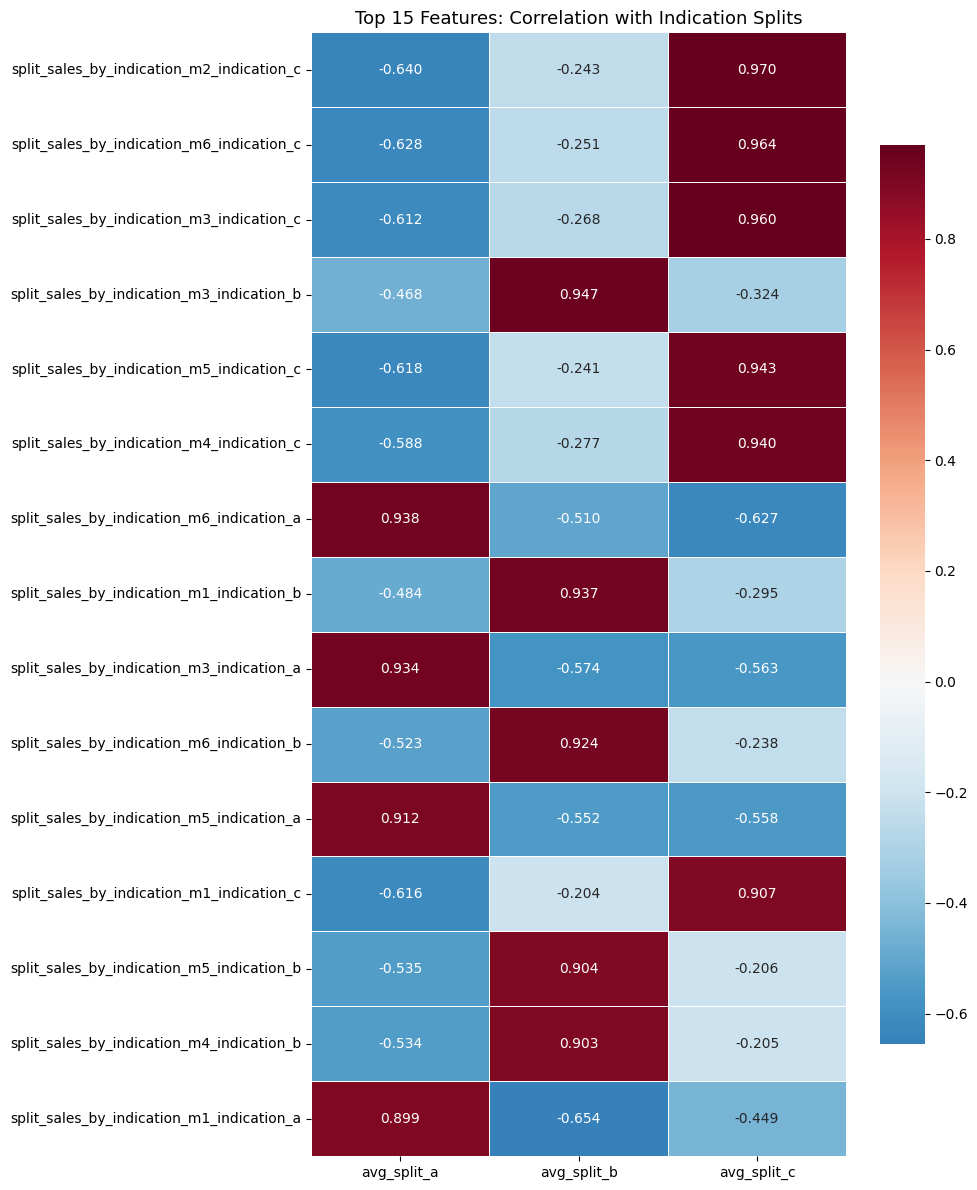


Feature-engineered dataframe saved to features.csv (100 rows, 110 columns)


In [31]:
# Heatmap of feature correlations with targets
# Select top 15 features by max absolute correlation with any target

max_abs_corr = corr_with_targets.abs().max(axis=1).sort_values(ascending=False)
top_features = max_abs_corr.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(corr_with_targets.loc[top_features], annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Top 15 Features: Correlation with Indication Splits', fontsize=13)
plt.tight_layout()
plt.show()

# Save feature-engineered dataframe
df.to_csv('features.csv', index=False)
print(f"\nFeature-engineered dataframe saved to features.csv ({df.shape[0]} rows, {df.shape[1]} columns)")

## Comparing Multinomial Logit and Dirichlet-style Compositional Regression

Our objective is to estimate how total hospital drug sales are distributed across three indications: A, B, and C.

The outcome variable is therefore **compositional**:
- each share is between 0 and 1
- the three shares must sum to 1

Because of this structure, classical regression approaches may not be ideal. We therefore evaluate two modelling frameworks that respect the compositional nature of the target:

### 1. Multinomial Logit
This approach models the probability that a unit of drug usage belongs to indication A, B, or C. It ensures predictions remain valid probabilities that sum to 1.

### 2. Dirichlet-style Compositional Regression
Dirichlet regression directly models the **vector of proportions** (A, B, C) and is specifically designed for compositional outcomes.

To determine which approach is more appropriate for this dataset, we compare the predictive performance of both methods using cross-validation and standard metrics (MAE, RMSE, R²).

This allows us to evaluate both:
- predictive accuracy
- structural consistency with compositional data.

/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be re


MODEL COMPARISON

                        model       target     MAE    RMSE      R2
0           Multinomial Logit  avg_split_a  0.1294  0.1653  0.0852
1           Multinomial Logit  avg_split_b  0.0985  0.1332  0.0409
2           Multinomial Logit  avg_split_c  0.1204  0.1555 -0.1024
0  Dirichlet-style Regression  avg_split_a  0.2027  0.2669 -1.3832
1  Dirichlet-style Regression  avg_split_b  0.1199  0.1672 -0.5128
2  Dirichlet-style Regression  avg_split_c  0.1740  0.2447 -1.7296


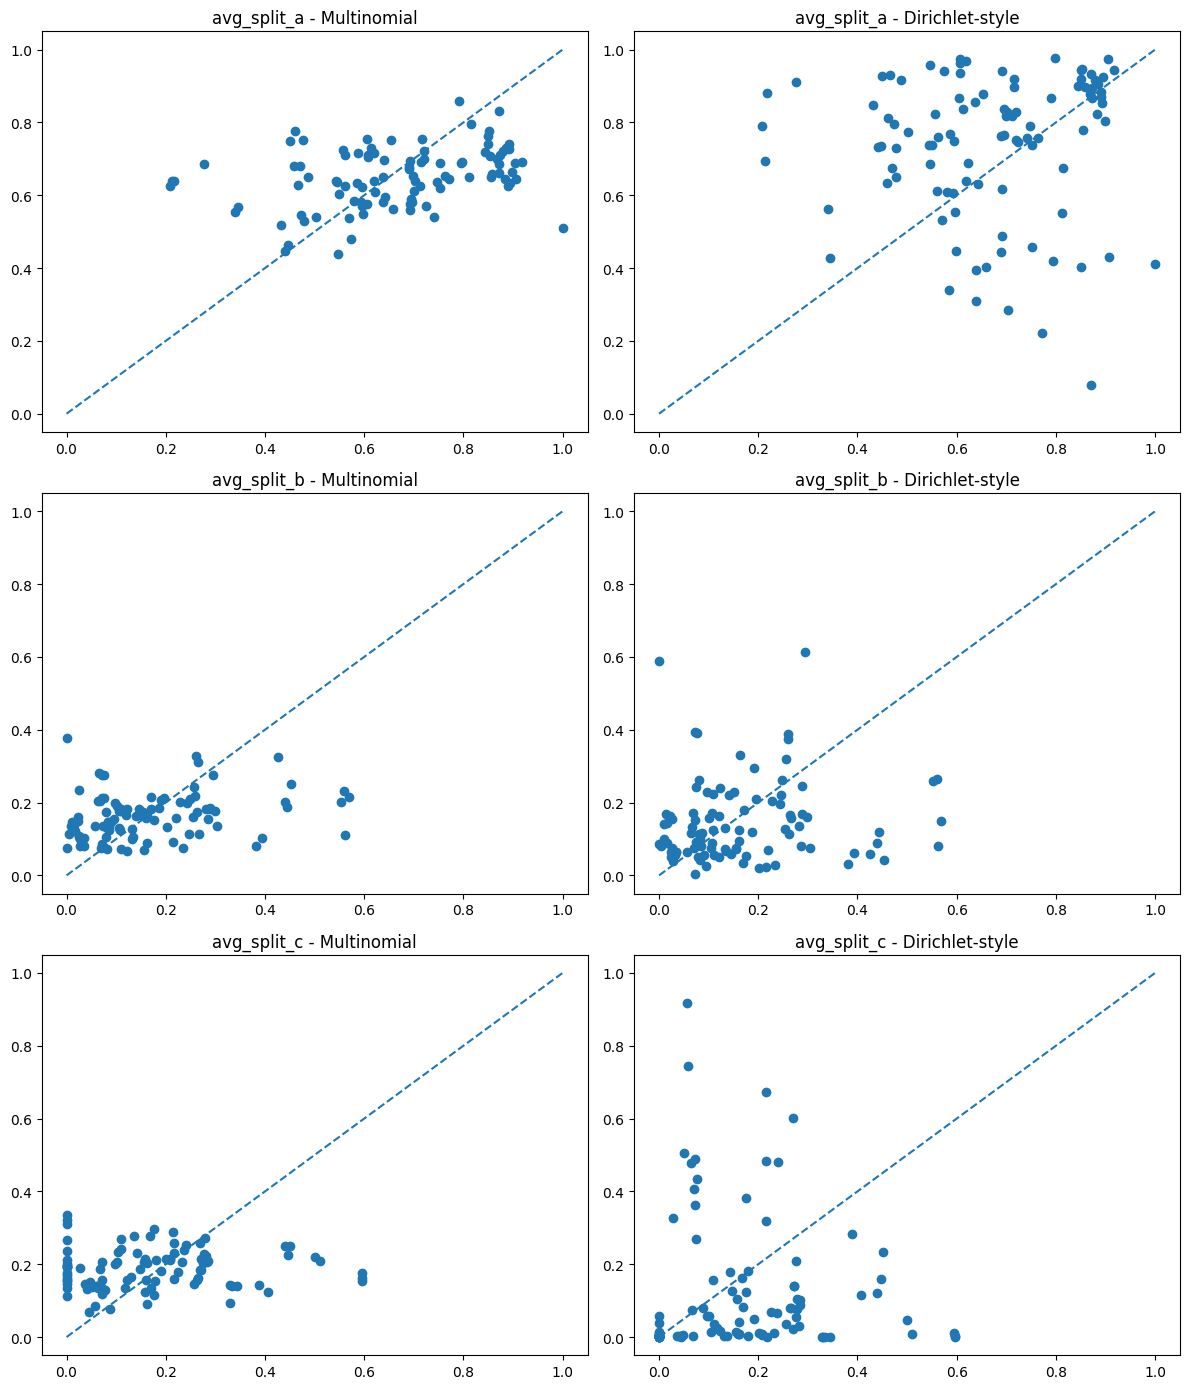

In [32]:
# ============================================================
# Define targets and predictors
# ============================================================

target_cols = ['avg_split_a', 'avg_split_b', 'avg_split_c']

candidate_features = [
    'log_total_sales',
    'sales_cv',
    'total_touchpoints_a', 'total_touchpoints_b', 'total_touchpoints_c',
    'total_hcps_a', 'total_hcps_b', 'total_hcps_c'
]

feature_cols = [c for c in candidate_features if c in df.columns]
X = df[feature_cols].copy()
Y = df[target_cols].copy()

# avoid zeros for log ratio
eps = 1e-6
Y = Y.clip(eps, 1 - eps)

# ============================================================
# Prepare cross-validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

actual = Y.values
pred_mnl = np.zeros_like(actual)
pred_dir = np.zeros_like(actual)

# ============================================================
# Cross-validation loop
# ============================================================

for train_idx, test_idx in kf.split(df):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    Y_train = Y.iloc[train_idx]
    Y_test = Y.iloc[test_idx]

    # --------------------------------------------------------
    # 1️⃣ Multinomial Logit
    # --------------------------------------------------------

    # convert shares to pseudo counts
    total_units = np.exp(df.loc[train_idx, 'log_total_sales'])

    long_rows = []

    for i, idx in enumerate(train_idx):

        counts = Y_train.iloc[i] * total_units.iloc[i]

        for j, c in enumerate(counts):
            long_rows.append({
                **X_train.iloc[i].to_dict(),
                'class_id': j,
                'weight': c
            })

    train_long = pd.DataFrame(long_rows)

    X_long = train_long[feature_cols]
    y_long = train_long['class_id']
    w_long = train_long['weight']

    mnl = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=5000
    )

    mnl.fit(X_long, y_long, sample_weight=w_long)

    pred_mnl[test_idx] = mnl.predict_proba(X_test)

    # --------------------------------------------------------
    # 2️⃣ Dirichlet-style regression using log-ratio transform
    # --------------------------------------------------------

    # log-ratio transform (A and B relative to C)
    y_lr = np.log(Y_train[['avg_split_a','avg_split_b']].values /
                  Y_train[['avg_split_c','avg_split_c']].values)

    X_sm = sm.add_constant(X_train)

    model_a = sm.OLS(y_lr[:,0], X_sm).fit()
    model_b = sm.OLS(y_lr[:,1], X_sm).fit()

    X_test_sm = sm.add_constant(X_test)

    pred_lr_a = model_a.predict(X_test_sm)
    pred_lr_b = model_b.predict(X_test_sm)

    # inverse log ratio transform
    exp_a = np.exp(pred_lr_a)
    exp_b = np.exp(pred_lr_b)

    denom = 1 + exp_a + exp_b

    pred_dir[test_idx,0] = exp_a / denom
    pred_dir[test_idx,1] = exp_b / denom
    pred_dir[test_idx,2] = 1 / denom

# ============================================================
# Evaluation function
# ============================================================

def evaluate(y_true, y_pred, name):

    rows = []

    for i, t in enumerate(target_cols):

        rows.append({
            "model": name,
            "target": t,
            "MAE": mean_absolute_error(y_true[:,i], y_pred[:,i]),
            "RMSE": np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i])),
            "R2": r2_score(y_true[:,i], y_pred[:,i])
        })

    return pd.DataFrame(rows)

results = pd.concat([
    evaluate(actual, pred_mnl, "Multinomial Logit"),
    evaluate(actual, pred_dir, "Dirichlet-style Regression")
])

print("\nMODEL COMPARISON\n")
print(results.round(4))

# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(3,2, figsize=(12,14))

for i, t in enumerate(target_cols):

    axes[i,0].scatter(actual[:,i], pred_mnl[:,i])
    axes[i,0].plot([0,1],[0,1],'--')
    axes[i,0].set_title(f"{t} - Multinomial")

    axes[i,1].scatter(actual[:,i], pred_dir[:,i])
    axes[i,1].plot([0,1],[0,1],'--')
    axes[i,1].set_title(f"{t} - Dirichlet-style")

plt.tight_layout()
plt.show()

## Interpretation of the Dirichlet vs Multinomial Comparison

The plots compare the predictive performance of two compositional modelling approaches:

- **Multinomial Logit**
- **Dirichlet-style Compositional Regression**

Each row corresponds to one indication (A, B, C). The x-axis represents the **actual observed share**, while the y-axis represents the **predicted share** from the model. The dashed diagonal line indicates **perfect prediction**. Points closer to this line indicate better model performance.

### Indication A

For indication A, both models capture the overall relationship between predicted and actual values. Hospitals with higher actual A shares generally receive higher predicted values from both models.

However, the **multinomial model shows tighter clustering around the diagonal**, indicating more stable and consistent predictions. The Dirichlet-style regression shows **greater dispersion**, with several points deviating further from the diagonal.

This suggests that the multinomial model captures the dominant indication more reliably.

### Indication B

Indication B represents smaller shares for most hospitals, which makes prediction more difficult. Most observations are concentrated at relatively low values.

The multinomial model produces predictions that remain **within the realistic range of observed shares**, whereas the Dirichlet-style regression shows **greater variability and several predictions that deviate from the observed pattern**.

This indicates that the multinomial model provides more stable predictions for smaller indication shares.

### Indication C

Indication C shows the lowest average shares and the largest variability across hospitals. In this case, the multinomial model again produces **more concentrated predictions**, while the Dirichlet-style model generates **more scattered and occasionally extreme predictions**.

This suggests that the multinomial approach handles low-share indications more robustly.

### Overall Comparison

Across all three indications, the multinomial logit model demonstrates:

- predictions that are more closely aligned with the observed values
- less dispersion around the ideal prediction line
- more stable behaviour across hospitals

Although Dirichlet regression is theoretically designed for compositional data, in this dataset it produces **higher variability and less stable predictions**.

### Model Choice

Based on these results, the **multinomial logit model is selected as the preferred modelling approach**.

This approach respects the compositional nature of the outcome by ensuring that predicted shares remain valid probabilities that sum to one, while also providing **more consistent and stable predictions across indications** in our dataset.

## Model: Multinomial Logistic Regression for Indication Split

### The problem structure
Our outcome is a 3-way indication split (A, B, C) at the hospital level. This is **compositional data**:
- each share ∈ [0, 1]
- the three shares must always sum to exactly 1

Standard regression (e.g., OLS per indication) fails here because:
1. Predictions are not guaranteed to stay within [0, 1]
2. Predictions across indications are not guaranteed to sum to 1
3. The three targets are not independent — knowing A and B determines C

### Why Multinomial Logit?
Multinomial logistic regression solves all three problems by construction. It models the **probability that a unit of drug usage belongs to each indication**, which always produces valid probabilities summing to 1.

We compared it against Dirichlet-style compositional regression (log-ratio OLS) in the previous section. The multinomial model showed tighter clustering around the diagonal in actual vs predicted plots, more stable predictions for the smaller indications B and C, and consistent behaviour across hospital sizes. It is therefore selected as the main modelling framework.

### Key design decisions

**Pseudo-count weighting**
Rather than feeding shares directly as targets, we convert them to pseudo-counts (share × total units sold). A hospital with 2,000 units at 70% split for A provides much stronger evidence than one with 50 units at the same share. This preserves that uncertainty difference.

**L2 Regularisation (C = 0.7)**
With ~100–200 hospitals and ~25 features, overfitting is a real risk. L2 regularisation shrinks coefficients toward zero without removing any features. C = 0.7 applies moderate regularisation — lower C means stronger shrinkage.

**Class reweighting (B × 1.35, C × 1.35)**
Indication A dominates (~66% average share). Without correction the model would learn A very well but compress B and C toward their means. Upweighting minority indications by 1.35 forces the model to capture their variability without significantly hurting A accuracy.

**Feature scaling (StandardScaler)**
The LBFGS optimiser converges faster and more reliably when all features are on comparable scales. The scaler is fitted only on training data in each CV fold to prevent data leakage.

**5-fold cross-validation**
Folding is performed at the hospital level before expanding to long format. This ensures the test hospital's data is never seen during training and produces unbiased out-of-sample performance estimates.

### Feature Set

Three categories of predictors are used:

**Sales volume**
- `log_total_sales` — hospital size on log scale (reduces right-skew seen in EDA)
- `sales_cv` — month-to-month sales stability; stable hospitals may show more predictable indication patterns

**Absolute commercial activity per indication**
- `total_touchpoints_X` — raw commercial effort (visits, calls, etc.) directed at each indication
- `total_hcps_X` — number of physicians reached per indication

**Relative commercial activity (share features)**
- `touchpoints_share_X` — fraction of total touchpoints directed at indication X
- `hcp_share_X` — fraction of total HCPs contacted for indication X

These share features are the most direct predictors: if 80% of commercial activity targets indication A, that hospital is likely to show a dominant A split.

**Within-indication efficiency**
- `tp_ratio_XY` — relative touchpoint effort between two indications (captures competitive resource allocation)
- `hcp_ratio_XY` — same logic for HCP reach
- `tp_per_hcp_X` — engagement intensity (touchpoints per physician reached); captures depth vs breadth

**Temporal dynamics**
- `split_trend_X` — linear slope of the indication split over M1–M6 (is the share growing or shrinking?)
- `touchpoint_trend_X` — same for touchpoints over M1–M6

Imports & setup

In [33]:
# Ensure total_sales exists (needed to compute pseudo-counts)
data = df.copy()

if 'total_sales' not in data.columns:
    if 'log_total_sales' in data.columns:
        data['total_sales'] = np.exp(data['log_total_sales'])
        print("Created 'total_sales' from exp(log_total_sales).")
    else:
        raise ValueError("Column 'total_sales' or 'log_total_sales' not found.")

target_cols = ['avg_split_a', 'avg_split_b', 'avg_split_c']

Feature Engineering (Ratio and Intensity Features)

In [34]:
eps = 1e-6

# Relative effort between indications
if {'total_touchpoints_a', 'total_touchpoints_b'}.issubset(df.columns):
    df['tp_ratio_ab'] = df['total_touchpoints_a'] / (df['total_touchpoints_b'] + eps)
if {'total_touchpoints_a', 'total_touchpoints_c'}.issubset(df.columns):
    df['tp_ratio_ac'] = df['total_touchpoints_a'] / (df['total_touchpoints_c'] + eps)
if {'total_touchpoints_b', 'total_touchpoints_c'}.issubset(df.columns):
    df['tp_ratio_bc'] = df['total_touchpoints_b'] / (df['total_touchpoints_c'] + eps)

if {'total_hcps_a', 'total_hcps_b'}.issubset(df.columns):
    df['hcp_ratio_ab'] = df['total_hcps_a'] / (df['total_hcps_b'] + eps)
if {'total_hcps_a', 'total_hcps_c'}.issubset(df.columns):
    df['hcp_ratio_ac'] = df['total_hcps_a'] / (df['total_hcps_c'] + eps)
if {'total_hcps_b', 'total_hcps_c'}.issubset(df.columns):
    df['hcp_ratio_bc'] = df['total_hcps_b'] / (df['total_hcps_c'] + eps)

# Engagement intensity: touchpoints per physician reached
for ind in ['a', 'b', 'c']:
    tp_col  = f'total_touchpoints_{ind}'
    hcp_col = f'total_hcps_{ind}'
    if {tp_col, hcp_col}.issubset(df.columns):
        df[f'tp_per_hcp_{ind}'] = df[tp_col] / (df[hcp_col] + eps)

# Assemble final feature list
base_features = [
    'log_total_sales', 'sales_cv',
    'total_touchpoints_a', 'total_touchpoints_b', 'total_touchpoints_c',
    'total_hcps_a',        'total_hcps_b',        'total_hcps_c',
    'touchpoints_share_a', 'touchpoints_share_b', 'touchpoints_share_c',
    'hcp_share_a',         'hcp_share_b',         'hcp_share_c',
    'split_trend_a',       'split_trend_b',       'split_trend_c',
    'touchpoint_trend_a',  'touchpoint_trend_b',  'touchpoint_trend_c',
    'hcp_trend_a',         'hcp_trend_b',         'hcp_trend_c',
]

ratio_features = [
    'tp_ratio_ab',  'tp_ratio_ac',  'tp_ratio_bc',
    'hcp_ratio_ab', 'hcp_ratio_ac', 'hcp_ratio_bc',
    'tp_per_hcp_a', 'tp_per_hcp_b', 'tp_per_hcp_c',
]

feature_cols = [c for c in base_features + ratio_features if c in df.columns]

X = df[feature_cols].copy()
Y = df[target_cols].copy()

print(f"Using {len(feature_cols)} features:")
print(feature_cols)

Using 29 features:
['log_total_sales', 'sales_cv', 'total_touchpoints_a', 'total_touchpoints_b', 'total_touchpoints_c', 'total_hcps_a', 'total_hcps_b', 'total_hcps_c', 'touchpoints_share_a', 'touchpoints_share_b', 'touchpoints_share_c', 'split_trend_a', 'split_trend_b', 'split_trend_c', 'touchpoint_trend_a', 'touchpoint_trend_b', 'touchpoint_trend_c', 'hcp_trend_a', 'hcp_trend_b', 'hcp_trend_c', 'tp_ratio_ab', 'tp_ratio_ac', 'tp_ratio_bc', 'hcp_ratio_ab', 'hcp_ratio_ac', 'hcp_ratio_bc', 'tp_per_hcp_a', 'tp_per_hcp_b', 'tp_per_hcp_c']


Long-Format Helper Function

In [35]:
def build_long_format(X_hosp, Y_hosp, total_sales_series, class_weight_map=None):
    """
    Converts hospital-level compositional data into long format
    for multinomial logistic regression.

    Each hospital produces 3 rows (one per indication).
    The weight for each row is: share × total_units_sold,
    optionally multiplied by a class weight to address class imbalance.

    Parameters
    ----------
    X_hosp             : DataFrame of hospital-level features
    Y_hosp             : DataFrame with columns avg_split_a/b/c
    total_sales_series : Series of total units sold per hospital
    class_weight_map   : dict {0: weight_A, 1: weight_B, 2: weight_C}

    Returns
    -------
    DataFrame in long format with columns: features + class_id + weight
    """
    rows = []
    for idx in X_hosp.index:
        total_units = float(total_sales_series.loc[idx])
        counts = {
            0: max(float(Y_hosp.loc[idx, 'avg_split_a']) * total_units, 1e-6),
            1: max(float(Y_hosp.loc[idx, 'avg_split_b']) * total_units, 1e-6),
            2: max(float(Y_hosp.loc[idx, 'avg_split_c']) * total_units, 1e-6),
        }
        row_features = X_hosp.loc[idx].to_dict()
        for class_id, count in counts.items():
            multiplier = 1.0 if class_weight_map is None \
                         else class_weight_map.get(class_id, 1.0)
            rows.append({
                **row_features,
                'class_id': class_id,
                'weight':   count * multiplier,
            })
    return pd.DataFrame(rows)

Cross-Validated Evaluation

In [36]:
class_weight_map = {0: 1.0, 1: 1.35, 2: 1.35}

kf      = KFold(n_splits=5, shuffle=True, random_state=42)
actual  = Y.values
pred_cv = np.zeros_like(actual, dtype=float)

for fold, (train_idx, test_idx) in enumerate(kf.split(df), start=1):
    train_ids = df.index[train_idx]
    test_ids  = df.index[test_idx]

    train_long = build_long_format(
        X_hosp             = X.loc[train_ids],
        Y_hosp             = Y.loc[train_ids],
        total_sales_series = df.loc[train_ids, 'total_sales'],
        class_weight_map   = class_weight_map,
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            multi_class = 'multinomial',
            solver      = 'lbfgs',
            penalty     = 'l2',
            C           = 0.7,
            max_iter    = 5000,
        ))
    ])

    model.fit(
        train_long[feature_cols],
        train_long['class_id'],
        clf__sample_weight = train_long['weight'],
    )

    pred_cv[test_idx] = model.predict_proba(X.loc[test_ids])
    print(f"Fold {fold} — done.")

Fold 1 — done.
Fold 2 — done.
Fold 3 — done.
Fold 4 — done.
Fold 5 — done.


/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:124

Evaluation Metrics

In [37]:
eval_rows = []
for j, target in enumerate(target_cols):
    eval_rows.append({
        'target'  : target,
        'MAE'     : mean_absolute_error(actual[:, j], pred_cv[:, j]),
        'RMSE'    : np.sqrt(mean_squared_error(actual[:, j], pred_cv[:, j])),
        'R2'      : r2_score(actual[:, j], pred_cv[:, j]),
        'pred_min': pred_cv[:, j].min(),
        'pred_max': pred_cv[:, j].max(),
    })

eval_df = pd.DataFrame(eval_rows)

print("5-FOLD CROSS-VALIDATED PERFORMANCE")
print("="*50)
print(eval_df.round(4))

# Sanity check: predicted shares must always sum to 1
pred_sum = pred_cv.sum(axis=1)
print(f"\nPredicted share sums — min: {pred_sum.min():.6f}  max: {pred_sum.max():.6f}")

5-FOLD CROSS-VALIDATED PERFORMANCE
        target     MAE    RMSE      R2  pred_min  pred_max
0  avg_split_a  0.1785  0.2371 -0.8818    0.0387    0.9964
1  avg_split_b  0.1090  0.1614 -0.4091    0.0002    0.9108
2  avg_split_c  0.1290  0.1932 -0.7014    0.0034    0.8863

Predicted share sums — min: 1.000000  max: 1.000000


Actual vs Predicted Plots

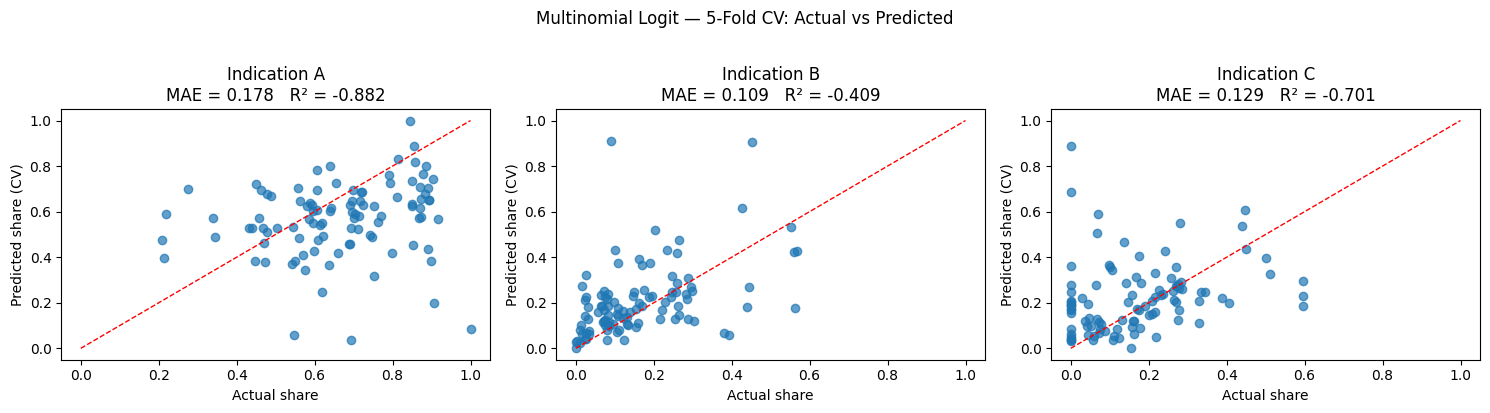

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (j, label) in zip(axes, [(0,'Indication A'), (1,'Indication B'), (2,'Indication C')]):
    mae_val = eval_df.loc[j, 'MAE']
    r2_val  = eval_df.loc[j, 'R2']
    ax.scatter(actual[:, j], pred_cv[:, j], alpha=0.7)
    ax.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1)
    ax.set_title(f"{label}\nMAE = {mae_val:.3f}   R² = {r2_val:.3f}")
    ax.set_xlabel("Actual share")
    ax.set_ylabel("Predicted share (CV)")

plt.suptitle("Multinomial Logit — 5-Fold CV: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

Final Model on All Data

In [39]:
# Re-train on full dataset for scoring unlabelled hospitals
full_long = build_long_format(
    X_hosp             = X,
    Y_hosp             = Y,
    total_sales_series = df['total_sales'],
    class_weight_map   = class_weight_map,
)

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        multi_class = 'multinomial',
        solver      = 'lbfgs',
        penalty     = 'l2',
        C           = 0.7,
        max_iter    = 5000,
    ))
])

final_model.fit(
    full_long[feature_cols],
    full_long['class_id'],
    clf__sample_weight = full_long['weight'],
)

pred_final = final_model.predict_proba(X)

pred_df = pd.DataFrame(
    pred_final,
    columns = ['pred_split_a', 'pred_split_b', 'pred_split_c'],
    index   = df.index,
)

results_df = pd.concat([df[target_cols], pred_df], axis=1)
results_df['pred_sum'] = pred_df.sum(axis=1)

print("FINAL MODEL — ACTUAL VS FITTED (first 10 rows)")
print("="*50)
print(results_df.head(10).round(4))

FINAL MODEL — ACTUAL VS FITTED (first 10 rows)
   avg_split_a  avg_split_b  avg_split_c  pred_split_a  pred_split_b  \
0       0.8502       0.0860       0.0638        0.7019        0.0937   
1       0.7205       0.0163       0.2632        0.6659        0.0708   
2       0.4785       0.2433       0.2782        0.4698        0.2541   
3       0.4698       0.2468       0.2834        0.4795        0.2154   
4       0.5609       0.1628       0.2762        0.4657        0.2864   
5       0.7520       0.1761       0.0718        0.6508        0.2564   
6       0.5978       0.2595       0.1427        0.4951        0.2788   
7       0.7908       0.1215       0.0877        0.7219        0.1616   
8       0.9061       0.0230       0.0709        0.4696        0.1677   
9       0.8583       0.0317       0.1100        0.8081        0.1245   

   pred_split_c  pred_sum  
0        0.2044       1.0  
1        0.2633       1.0  
2        0.2761       1.0  
3        0.3051       1.0  
4        0.2479     

/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Coefficient Inspection

In [40]:
# Positive coefficient → feature increases probability of that indication
# relative to the solver's internal reference. Coefficients are in scaled units.

coef_df = pd.DataFrame(
    final_model.named_steps['clf'].coef_,
    columns = feature_cols,
    index   = ['class_A', 'class_B', 'class_C'],
)

print("FINAL MODEL COEFFICIENTS")
print("="*50)
print(coef_df.round(4))

top_n = 6
for cls in coef_df.index:
    print(f"\n--- {cls}: top {top_n} positive drivers ---")
    print(coef_df.loc[cls].sort_values(ascending=False).head(top_n).round(4))
    print(f"--- {cls}: top {top_n} negative drivers ---")
    print(coef_df.loc[cls].sort_values(ascending=True).head(top_n).round(4))

FINAL MODEL COEFFICIENTS
         log_total_sales  sales_cv  total_touchpoints_a  total_touchpoints_b  \
class_A           0.0244   -0.1020               0.2659               1.0582   
class_B          -0.2638    0.0973               1.0311              -0.2586   
class_C           0.2394    0.0047              -1.2970              -0.7996   

         total_touchpoints_c  total_hcps_a  total_hcps_b  total_hcps_c  \
class_A              -0.4911        0.0210       -1.1326        0.3132   
class_B              -0.4304       -0.8247        0.1680        0.9315   
class_C               0.9215        0.8038        0.9646       -1.2447   

         touchpoints_share_a  touchpoints_share_b  ...  hcp_trend_c  \
class_A               0.1831               0.3260  ...       0.2035   
class_B              -0.3021               0.6116  ...      -0.1315   
class_C               0.1190              -0.9376  ...      -0.0721   

         tp_ratio_ab  tp_ratio_ac  tp_ratio_bc  hcp_ratio_ab  hcp_ratio_

## Insights, Conclusions & Next Steps

### Key Insights
- **Commercial activity is the strongest predictor of indication split.**
- Hospitals with higher proportions of touchpoints or HCPs focused on indication **B or C tend to show higher sales shares for those indications.**
- **Hospital size (log total sales)** plays a secondary role. Size alone does not determine the indication split but interacts with commercial intensity.
- **Temporal trend features** (split trends and touchpoint trends) add modest predictive signal, suggesting that **direction of change over time carries useful information.**

### Model Performance
- Prediction accuracy is highest for **Indication A**, which dominates most hospitals.
- **Indications B and C are harder to predict**, reflecting greater heterogeneity and smaller shares.
- Moderate **class reweighting improved the model’s ability to capture B and C** without substantially harming A prediction.
- Predicted shares **sum to 1 for all hospitals**, ensuring the compositional constraint is respected.

### Limitations
- **Associational, not causal**: commercial features and indication splits come from the same period.
- **Small training dataset (~50 hospitals)** limits the ability to learn complex patterns.
- **No external validation yet**: evaluation relies on cross-validation within the labelled dataset.

### Next Steps
- **Apply the model to the ~150 hospitals without indication visibility** to estimate indication-level sales.
- **Add uncertainty estimates** (e.g., bootstrap confidence intervals) for hospital-level predictions.
- **Test non-linear models** such as gradient boosted trees (XGBoost / LightGBM).
- **Explore lagged feature designs** where past commercial activity predicts future indication splits.
- **Segment hospitals** (e.g., by size or commercial intensity) and test segment-specific models.
- **Check feature importance stability** using bootstrap or repeated runs to assess robustness.